# Практическая работа № 3

**Цель работы:** познакомиться на практике с механизмами внимания как способом повышения качества нейронных сетей при обработке данных. Исследовать применение attention-модулей в классических архитектурах.

**Задачи:**

1. Изучить выбранную архитектуру нейронной сети.
2. Выбрать и описать датасет.
3. Построить и обучить модель.
4. Проанализировать процесс обучения.
5. Провести серию экспериментов с гиперпараметрами.
6. Сравнить результаты и сделать выводы.

---

**Теоретическая справка**

**Выбранная архитектура нейронной сети:** для работы я выбрала сверточную нейронную сеть (CNN), дополненную механизмом внимания. Будет использоваться для задачи многоклассовой классификации изображений.

Сверточные нейронные сети предназначены для обработки данных с пространственной структурой. Их основная особенность заключается в использовании сверточных слоёв, которые автоматически выделяют значимые признаки: границы, текстуры, формы и более сложные визуальные паттерны.

Классическая структура CNN включает: сверточные слои — извлечение признаков, функции активации — добавление нелинейности, pooling-слои — уменьшение размерности, полносвязные слои — итоговая классификация.


**Выбранный механизм attention:** для улучшения качества модели будет использоваться механизм внимания SE-block (Squeeze-and-Excitation block). Он является классическим attention-модулем, который усиливает наиболее важные каналы признаков и ослабляет менее значимые.

Принцип работы: Squeeze — глобальное усреднение признаков по пространственным координатам, Excitation — обучение весов важности для каждого канала, Scale — масштабирование исходных признаков с учётом найденных весов. Таким образом, сеть получает возможность адаптивно выделять наиболее информативные признаки.

SE-block хорошо интегрируется в классические CNN, не требует сложной архитектуры и существенно улучшает качество без большого увеличения вычислительных затрат. Для задачи классификации изображений важно не только выделять локальные признаки, но и понимать, какие каналы признаков наиболее значимы для итогового решения, что может обеспечить SE-block.

---

**Используемые инструменты**

* PyTorch — построение и обучение модели
* NumPy — работа с массивами
* Matplotlib — построение графиков
* Scikit-learn — вычисление метрик качества
* Pandas — анализ данных

In [1]:
# Используемые библиотеки
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

## 1. Выбранный датасет

Для данной работы выбран Apple Leaf Disease Dataset: https://www.kaggle.com/datasets/nirmalsankalana/apple-leaf-disease-dataset

Датасет содержит изображения листьев яблони, относящихся к разным состояниям здоровья. Будет решаться задача классификации.

Изображения организованы по папкам, каждая из которых соответствует отдельному классу:
* healthy — здоровые листья
* scab — листья с заболеванием парша
* rust — листья с заболеванием ржавчина

Каждое изображение представляет собой фотографию листа с различными визуальными особенностями: цвет, текстура, наличие пятен и повреждений.

Датасет подходит для работы, так как: это подходящий тип данных для CNN, задача многоклассовой классификации соответствует архитектуре, визуальные различия между классами позволят оценить эффективность attention-модуля.


In [2]:
!unzip -q archive.zip

In [5]:
# Трансформации изображений
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Загрузка датасета
data_path = "data"
full_dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Разделение на train, test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_data, test_data = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# Названия классов
classes = full_dataset.classes

print(f"Классы: {classes}")
print(f"Всего изображений: {len(full_dataset)}")
print(f"Обучающая выборка: {len(train_data)}")
print(f"Тестовая выборка: {len(test_data)}")

Классы: ['healthy', 'rust', 'scab']
Всего изображений: 1730
Обучающая выборка: 1384
Тестовая выборка: 346


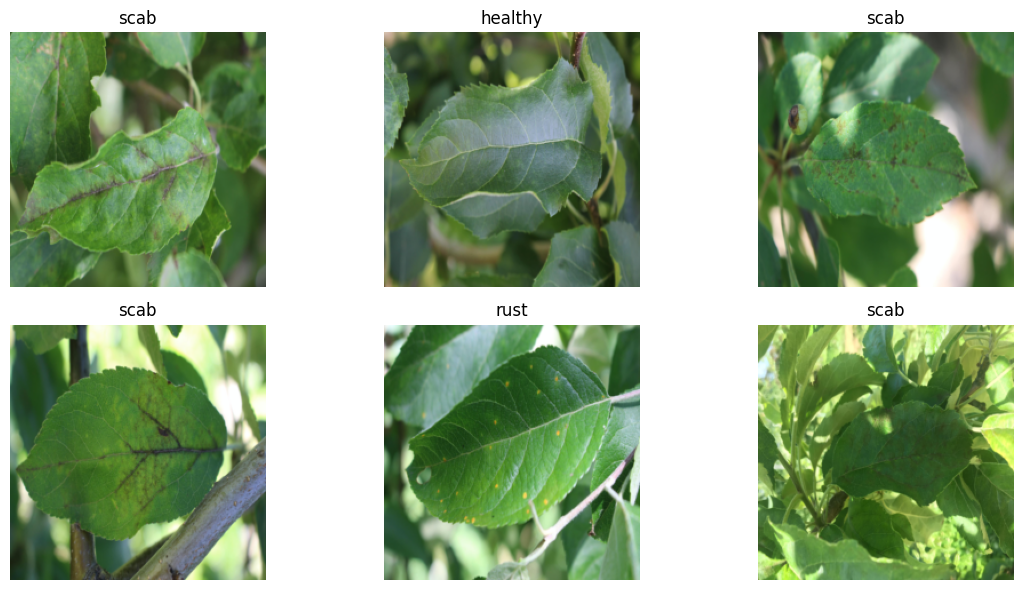

In [6]:
# Визуализация нескольких примеров
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    imshow(images[i])
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Построение модели с механизмом внимания

Создадим простую сверточную сеть, где после каждого крупного блока свертки будет стоять SE-block.

Реализуем SE-block. Сначала делаем сжатие squeeze: превращаем картинку в вектор, где каждое число — это средняя интенсивность одного канала (Global Average Pooling). Затем excitation: пропускаем этот вектор через два полносвязных слоя. Здесь решается, какие каналы сейчас важны, а какие нет. На выходе используем Sigmoid, так как нужно получить коэффициенты важности от 0 до 1. В конце масштабирование scale: умножаем исходные каналы на полученные веса.

In [7]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        # Сжимаем пространственную информацию
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        # Обучаем веса для каналов
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze
        y = self.avg_pool(x).view(b, c)
        # Excitation
        y = self.fc(y).view(b, c, 1, 1)
        # Scale
        return x * y.expand_as(x)

Теперь построим основную архитектуру модели. В качестве базовой структуры классическая CNN, состоящая из трёх сверточных блоков. Каждый блок включает: сверточный слой для извлечения признаков, batch normalization для стабилизации обучения, функцию активации ReLU (она простая, не зануляет градиенты так сильно, как сигмоида, и работает быстрее), pooling для уменьшения размерности, attention-модуль SE-block для усиления значимых признаков.

Таким образом, после каждого этапа извлечения признаков модель дополнительно оценивает важность каналов и адаптивно перераспределяет внимание.

После сверточных блоков полученные признаки разворачиваются в вектор и передаются в полносвязные слои для окончательной классификации.

In [8]:
class SimpleAttentionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleAttentionCNN, self).__init__()

        # Слой 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.se1 = SEBlock(32)

        # Слой 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.se2 = SEBlock(64)

        # Слой 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.se3 = SEBlock(128)

        self.pool = nn.MaxPool2d(2, 2)

        # Полносвязные слои
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.se1(x) # Применяем внимание

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.se2(x) # Применяем внимание

        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.se3(x) # Применяем внимание

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleAttentionCNN(num_classes=len(classes))
print(model)

SimpleAttentionCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (se1): SEBlock(
    (avg_pool): AdaptiveAvgPool2d(output_size=1)
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=2, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=2, out_features=32, bias=False)
      (3): Sigmoid()
    )
  )
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (se2): SEBlock(
    (avg_pool): AdaptiveAvgPool2d(output_size=1)
    (fc): Sequential(
      (0): Linear(in_features=64, out_features=4, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=4, out_features=64, bias=False)
      (3): Sigmoid()
    )
  )
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(12

Теперь обучение модели. В качестве функции потерь используется CrossEntropyLoss, так как решается задача многоклассовой классификации. Для оптимизации Adam, он хорошо подходит для глубоких нейронных сетей. На каждой эпохе фиксируются: значение функции потерь на обучающей выборке, значение функции потерь и точность классификации на тестовой выборке. Основная метрика accuracy, так как наглядно показывает процент правильно угаданных диагнозов листьев.

Вычисления выполняются на GPU для ускорения процесса.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30

history = {
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(epochs):
    # Train
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Test
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    acc = 100 * correct / total

    history["train_loss"].append(avg_train_loss)
    history["test_loss"].append(avg_test_loss)
    history["test_acc"].append(acc)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}, Accuracy = {acc:.2f}%")

Epoch 1/30: 100%|██████████| 44/44 [00:44<00:00,  1.02s/it]


Epoch 1: Train Loss = 6.0000, Test Loss = 1.0822, Accuracy = 37.57%


Epoch 2/30: 100%|██████████| 44/44 [00:42<00:00,  1.05it/s]


Epoch 2: Train Loss = 1.0777, Test Loss = 1.0466, Accuracy = 41.04%


Epoch 3/30: 100%|██████████| 44/44 [00:44<00:00,  1.02s/it]


...

Epoch 28: Train Loss = 0.1870, Test Loss = 0.5223, Accuracy = 85.26%


Epoch 29/30: 100%|██████████| 44/44 [00:43<00:00,  1.01it/s]


Epoch 29: Train Loss = 0.1629, Test Loss = 0.4445, Accuracy = 86.71%


Epoch 30/30: 100%|██████████| 44/44 [00:42<00:00,  1.03it/s]


Epoch 30: Train Loss = 0.1425, Test Loss = 0.4630, Accuracy = 87.86%


Графики для анализа динамики обучения.

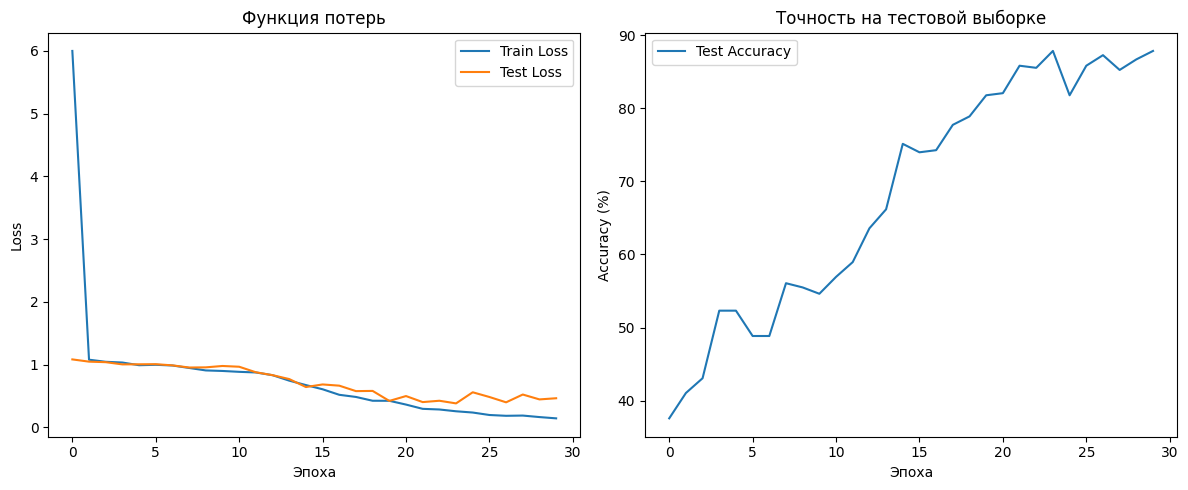

In [10]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.title("Функция потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["test_acc"], label="Test Accuracy")
plt.title("Точность на тестовой выборке")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

В процессе обучения модели наблюдалась постепенная сходимость функции потерь и рост точности классификации. На начальных эпохах модель показывала низкое качество, значение функции потерь было высоким. Модель ещё не успела выучить значимые признаки изображений. Начиная с 7–10 эпохи улучшение качества, функция потерь на обучающей выборке стабильно уменьшается,
точность постепенно растёт. После 15-й эпохи точность увеличивается до 70–80%, значение функции потерь уменьшается до 0.1425 на обучении. Модель успешно обучается и начинает хорошо различать классы.

На графике видны колебания точности и функции потерь на тестовой выборке. Это может означать, что Learning Rate слишком высокий для этой стадии. Также, обучение происходит батчами, и на каждой эпохе данные перемешиваются, из-за этого модель может переучиться под конкретные примеры. Датасет не очень большой, модель может сильно зависеть от конкретных примеров. SE-block динамически изменяет веса каналов, что добавляет гибкости, но может вызывать нестабильность.

К концу обучения наблюдаются признаки небольшого переобучения: train loss продолжает уменьшаться, а test loss начинает расти. Это означает, что модель хорошо запоминает обучающую выборку, но хуже обобщает на новые данные.

В целом, модель успешно обучилась и достигла высокой точности 87%, учитывая простую архитектуру. SE-block помог выделять важные признаки и улучшил качество классификации.

## 3. Эксперимент с гиперпараметрами

Поменяем несколько параметров сразу, чтобы попробовать улучшить модель и повысить её точность.

Заменим ReLU на LeakyReLU. Она пропускает небольшой отрицательный градиент, что помогает избежать проблемы умирающих нейронов и делает обучение более плавным. В гиперпараметрах attention изменим reduction с 16 на 8. Это сделает SE-блок более внимательным, давая ему больше параметров для вычисления важности каналов.

Оптимизатор оставим Adam, но уменьшим Learning Rate в 2 раза и добавим Weight Decay (L2-регуляризация). Это заставит модель штрафовать слишком большие веса, что должно остановить рост Test Loss.

In [11]:
# SE-block
class SEBlock_Exp(nn.Module):
    def __init__(self, channels, reduction=8): # Поменяли reduction
        super(SEBlock_Exp, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.LeakyReLU(0.1, inplace=True), # Поменяли ReLU на LeakyReLU
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Класс модели
class ExperimentalAttentionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(ExperimentalAttentionCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.se1 = SEBlock_Exp(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.se2 = SEBlock_Exp(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.se3 = SEBlock_Exp(128)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # LeakyReLU вместо ReLU
        x = self.pool(F.leaky_relu(self.bn1(self.conv1(x)), 0.1))
        x = self.se1(x)

        x = self.pool(F.leaky_relu(self.bn2(self.conv2(x)), 0.1))
        x = self.se2(x)

        x = self.pool(F.leaky_relu(self.bn3(self.conv3(x)), 0.1))
        x = self.se3(x)

        x = x.view(x.size(0), -1)
        x = F.leaky_relu(self.fc1(x), 0.1)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

exp_model = ExperimentalAttentionCNN(num_classes=len(classes)).to(device)

Обучение с новыми гиперпараметрами. Добавляем weight_decay в оптимизатор.

In [12]:
criterion = nn.CrossEntropyLoss()
# LR меньше, weight_decay для борьбы с переобучением
optimizer = optim.Adam(exp_model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 30
exp_history = {
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(epochs):
    exp_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Exp Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = exp_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    exp_model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = exp_model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    exp_history["train_loss"].append(running_loss / len(train_loader))
    exp_history["test_loss"].append(test_loss / len(test_loader))
    exp_history["test_acc"].append(acc)

    print(f"Epoch {epoch+1}: Train Loss = {exp_history['train_loss'][-1]:.4f}, Test Loss = {exp_history['test_loss'][-1]:.4f}, Accuracy = {acc:.2f}%")

Exp Epoch 1/30: 100%|██████████| 44/44 [00:43<00:00,  1.01it/s]


Epoch 1: Train Loss = 4.5794, Test Loss = 1.4088, Accuracy = 41.91%


Exp Epoch 2/30: 100%|██████████| 44/44 [00:44<00:00,  1.00s/it]


Epoch 2: Train Loss = 1.3336, Test Loss = 1.1859, Accuracy = 47.11%


Exp Epoch 3/30: 100%|██████████| 44/44 [00:42<00:00,  1.04it/s]


...

Epoch 28: Train Loss = 0.0299, Test Loss = 0.9134, Accuracy = 79.19%


Exp Epoch 29/30: 100%|██████████| 44/44 [00:43<00:00,  1.01it/s]


Epoch 29: Train Loss = 0.0389, Test Loss = 1.1673, Accuracy = 75.72%


Exp Epoch 30/30: 100%|██████████| 44/44 [00:46<00:00,  1.05s/it]


Epoch 30: Train Loss = 0.0317, Test Loss = 1.0893, Accuracy = 76.59%


Для сравнения выведем графики базовой и экспериментальной модели.

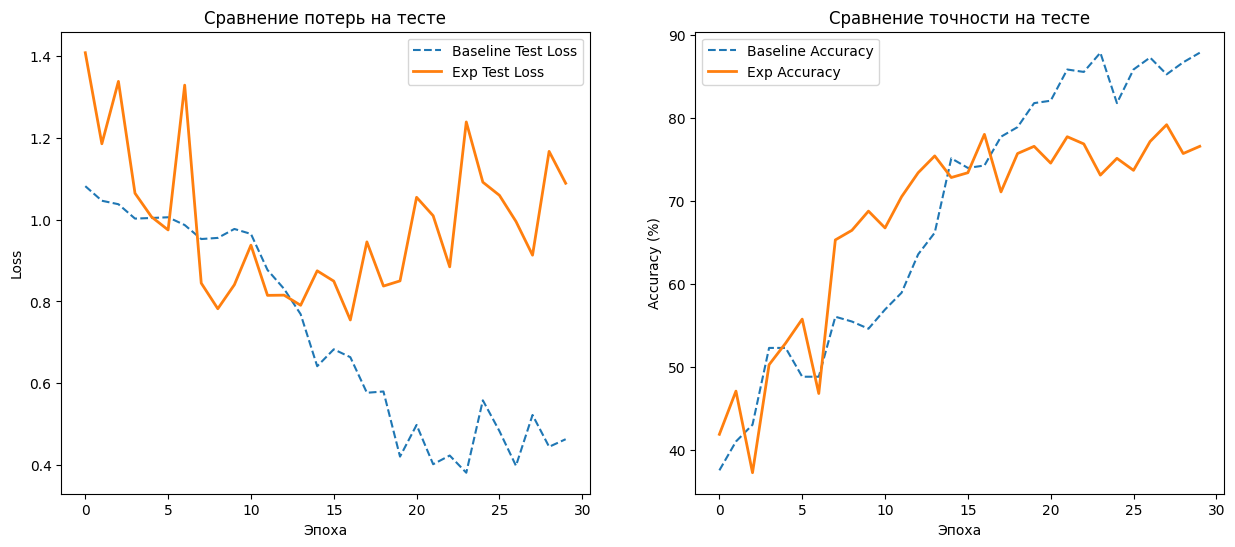

In [13]:
plt.figure(figsize=(15, 6))

# Сравнение Loss
plt.subplot(1, 2, 1)
plt.plot(history["test_loss"], label="Baseline Test Loss", linestyle='--')
plt.plot(exp_history["test_loss"], label="Exp Test Loss", linewidth=2)
plt.title("Сравнение потерь на тесте")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()

# Сравнение Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["test_acc"], label="Baseline Accuracy", linestyle='--')
plt.plot(exp_history["test_acc"], label="Exp Accuracy", linewidth=2)
plt.title("Сравнение точности на тесте")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

Train Loss снизился до очень низких значений (0.03), что говорит о том, что модель практически идеально выучила тренировочный набор данных. Test Loss наоборот после 17 эпохи начал расти с сильными скачками. Пиковая точность составила 79.19%, что ниже показателей базовой модели. График также с сильными скачками.

Уменьшение коэффициента редукции в attention дало модели больше мощности для извлечения признаков, однако для такого небольшого датасета избыточная сложность привела к тому, что сеть начала запоминать конкретные картинки. Функция активации LeakyReLU помогла модели быстрее стартовать (на графике точности видно, что оранжевая линия в начале идет выше синей), но дальше не улучшила результаты. Несмотря на добавление регуляризации и уменьшение шага обучения, модель все равно переобучилась (огромный разрыв между train loss и test loss). Прямая loss новой модели находится значительно выше прошлой модели и ведет себя крайне нестабильно. На графике точности видно, что базовая модель обучалась медленнее, но в итоге оказалась более устойчивой и показала лучший результат.

Внедрение более сложного механизма внимания и использование LeakyReLU повысили емкость сети, но в условиях ограниченного объема данных это привело к деградации, модель стала слишком сложной для текущей задачи. В данном случае базовая конфигурация оказалась более сбалансированной для предотвращения переобучения.

### Углубление архитектуры и смена оптимизатора на SGD

Проверим, поможет ли нейросети добавление еще одного блока сверток и использование классического метода обучения вместо адаптивного.

Добавим четвертый сверточный блок. Заменим Adam на SGD. Adam обучается быстрее, но SGD с хорошим моментом часто находит более качественные минимумы функции потерь, что может дать лучшую точность на тесте. В гиперпараметрах оставим reduction=16, чтобы посмотреть, как стандартное внимание работает в более глубокой сети.

In [14]:
class DeepAttentionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(DeepAttentionCNN, self).__init__()

        # Слой 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            SEBlock(32, reduction=16)
        )

        # Слой 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            SEBlock(64, reduction=16)
        )

        # Слой 3
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            SEBlock(128, reduction=16)
        )

        # Слой 4
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            SEBlock(256, reduction=16)
        )

        self.fc = nn.Sequential(
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x) # Четвертый уровень внимания

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

deep_model = DeepAttentionCNN(num_classes=len(classes)).to(device)

Для SGD обычно ставят learning rate выше, чем для Adam.

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(deep_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

epochs = 30
deep_history = {
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(epochs):
    deep_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Deep Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = deep_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    deep_model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = deep_model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    deep_history["train_loss"].append(running_loss / len(train_loader))
    deep_history["test_loss"].append(test_loss / len(test_loader))
    deep_history["test_acc"].append(acc)

    print(f"Epoch {epoch+1}: Train Loss = {deep_history['train_loss'][-1]:.4f}, Test Loss = {deep_history['test_loss'][-1]:.4f}, Accuracy = {acc:.2f}%")

Deep Epoch 1/30: 100%|██████████| 44/44 [00:44<00:00,  1.01s/it]


Epoch 1: Train Loss = 1.1647, Test Loss = 0.9131, Accuracy = 58.67%


Deep Epoch 2/30: 100%|██████████| 44/44 [00:44<00:00,  1.00s/it]


Epoch 2: Train Loss = 0.8149, Test Loss = 0.9862, Accuracy = 43.35%


Deep Epoch 3/30: 100%|██████████| 44/44 [00:44<00:00,  1.02s/it]


...

Epoch 28: Train Loss = 0.1480, Test Loss = 0.3135, Accuracy = 92.77%


Deep Epoch 29/30: 100%|██████████| 44/44 [00:44<00:00,  1.01s/it]


Epoch 29: Train Loss = 0.2058, Test Loss = 0.3616, Accuracy = 89.88%


Deep Epoch 30/30: 100%|██████████| 44/44 [00:44<00:00,  1.00s/it]


Epoch 30: Train Loss = 0.2735, Test Loss = 0.4551, Accuracy = 89.60%


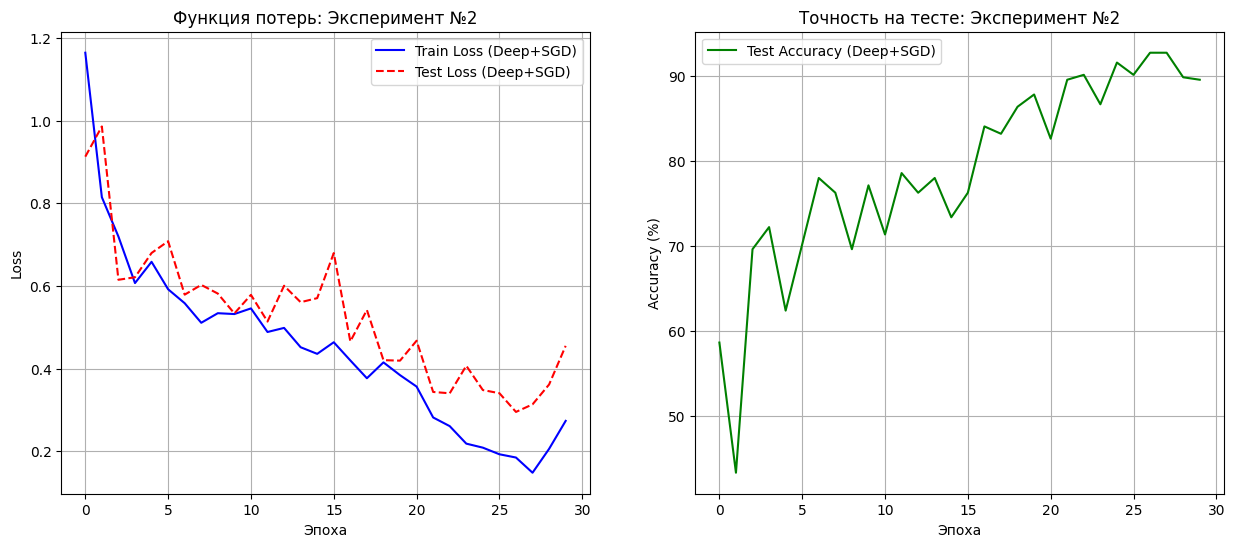

In [16]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(deep_history["train_loss"], label="Train Loss (Deep+SGD)", color='blue')
plt.plot(deep_history["test_loss"], label="Test Loss (Deep+SGD)", color='red', linestyle='--')
plt.title("Функция потерь: Эксперимент №2")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(deep_history["test_acc"], label="Test Accuracy (Deep+SGD)", color='green')
plt.title("Точность на тесте: Эксперимент №2")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.show()

Модель достигла пика в 92.77% на последних эпохах. Это лучший результат из всех моделей. В отличие от первого эксперимента, где графики скакали, здесь более стабильный восходящий тренд.

Добавление 4 сверточного блока позволило нейросети извлекать более высокоуровневые признаки. Если первые слои реагируют на края и цвета, то четвертый слой в сочетании с Attention смог распознавать сложные текстуры болезней. Оптимизатор SGD с моментом обеспечивает лучшую обобщающую способность по сравнению с Adam в данной архитектуре.

На графике видно, что Train Loss и Test Loss снижаются практически синхронно, модель учится и при этом сохраняет способность к обобщению. Небольшой подъем Test Loss в самом конце говорит о начале легкого переобучения, но оно наступило позже и в меньшей степени, чем в предыдущих моделях.

Эксперимент продемонстрировал наилучшую эффективность. Сочетание увеличенной глубины сети и оптимизатора SGD позволило модели достичь самой высокой точности.

### Сравнение точности всех моделей.

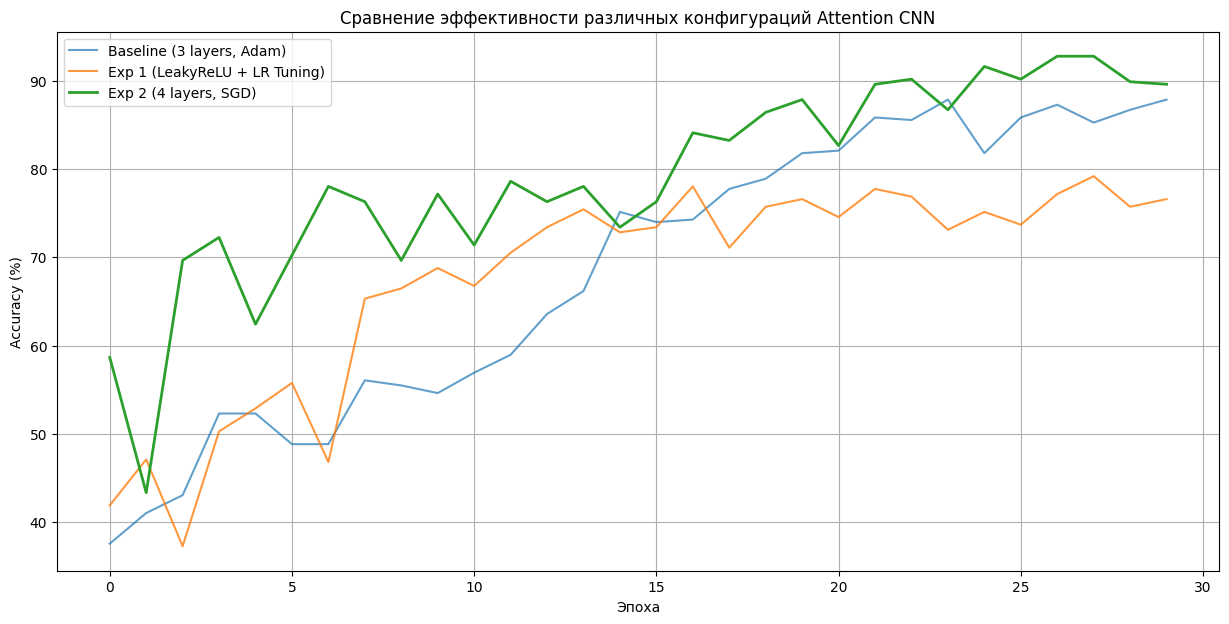

In [17]:
plt.figure(figsize=(15, 7))

plt.plot(history["test_acc"], label="Baseline (3 layers, Adam)", alpha=0.7)
plt.plot(exp_history["test_acc"], label="Exp 1 (LeakyReLU + LR Tuning)", alpha=0.8)
plt.plot(deep_history["test_acc"], label="Exp 2 (4 layers, SGD)", linewidth=2)

plt.title("Сравнение эффективности различных конфигураций Attention CNN")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Конфигурация с 4 сверточными слоями и оптимизатором SGD продемонстрировала наилучшие результаты, преодолев порог в 90% точности.

Это доказывает, что для классификации болезней яблони, где признаки могут быть мелкими и сложными, глубина сети играет решающую роль. Дополнительный уровень позволил механизму внимания работать с более абстрактными и специфичными признаками.

График базовой модели самый плавный, что говорит о хорошей сбалансированности стандартных гиперпараметров для данного набора данных. Попытка тонкой настройки оказалась наименее эффективной, усложнение при малом количестве слоев привело к избыточности.

## Вывод

В ходе выполнения работы была спроектирована и исследована сверточная нейронная сеть, усиленная механизмом канального внимания. Основной задачей была классификация трех состояний листьев яблони. Практика подтвердила, что блоки внимания эффективно подсвечивают нужные каналы признаков.

Самым значимым фактором успеха оказалось углубление сети до 4-х слоев. Опыты с изменением параметров SE-блока показали, что чрезмерное усложнение внимания на неглубокой сети приводит к переобучению и падению точности. Оптимизатор SGD в данной задаче обеспечивает более стабильную сходимость к качественному результату, чем адаптивный Adam, который склонен к переобучению на малых датасетах. Использование ReLU оказалось оправданным из-за простоты и эффективности.

Наилучшей конфигурацией стала 4-слойная CNN с SE-блоками, обученная с помощью оптимизатора SGD. Модель показала высокую обобщающую способность и стабильность, успешно решив задачу классификации с точностью 92.77%. Работа наглядно продемонстрировала, что даже без использования тяжелых трансформеров, классические CNN с блоками внимания способны показывать хорошие результаты при правильном подборе гиперпараметров.